<a href="https://colab.research.google.com/github/Yusra-Zafar/Transfer-learning-on-VGG16-with-PyTorch/blob/main/Transfer_Learning_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Code Flow
1. Import VGG16
2. Detach classifier
3. Attach our own classifier
4. Freeze feature extraction layers
5. Train the model


VGG16 stands for **Visual Geometry Group 16**, which refers to a convolutional neural network (CNN) architecture proposed by the Visual Geometry Group at the University of Oxford. The "16" in VGG16 indicates that the model has 16 layers that contain weights, including 13 convolutional layers and 3 fully connected layers

The problem is that the VGG16 model is pretrained on colored images, while our data is in grayscale. So we have to preprocess our images to make them compatible with this model.


The proprocessing requirements are mentioned on the [VGG16 model's PyTorch page](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.vgg16.html?highlight=vgg16#torchvision.models.vgg16).


"The inference transforms are available at VGG16_Weights.IMAGENET1K_V1.transforms and perform the following preprocessing operations: Accepts PIL.Image, batched (B, C, H, W) and single (C, H, W) image torch.Tensor objects. The images are resized to resize_size=[256] using interpolation=InterpolationMode.BILINEAR, followed by a central crop of crop_size=[224]. Finally the values are first rescaled to [0.0, 1.0] and then normalized using mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225]."

## Our preprocessing steps are as follows:

1. reshape (28,28)
2. datatype -> np.uint8 (to convert to PIL)
3. 1D -> 3D (3,28,28)
4. tensor -> PIL
5. resize (3,256,256)
6. center crop (224, 224)
7. tensor (scale)
8. normalize with given values  mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225].

In [ ]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
# set manual seed
torch.manual_seed(42)

In [ ]:
# check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# import dataset
df = pd.read_csv('/content/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0.0,7.0,0.0,50.0,205.0,196.0,213.0,165.0,0.0,0.0
1,7,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,1,0,0,0,...,142.0,142.0,142.0,21.0,0.0,3.0,0.0,0.0,0.0,0.0
3,8,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8,0,0,0,0,0,0,0,0,0,...,213.0,203.0,174.0,151.0,188.0,10.0,0.0,0.0,0.0,0.0


In [ ]:
# Fill NaN values with 0, as pixel data should be numerical.
df = df.fillna(0)

In [ ]:
df.shape

(940, 785)

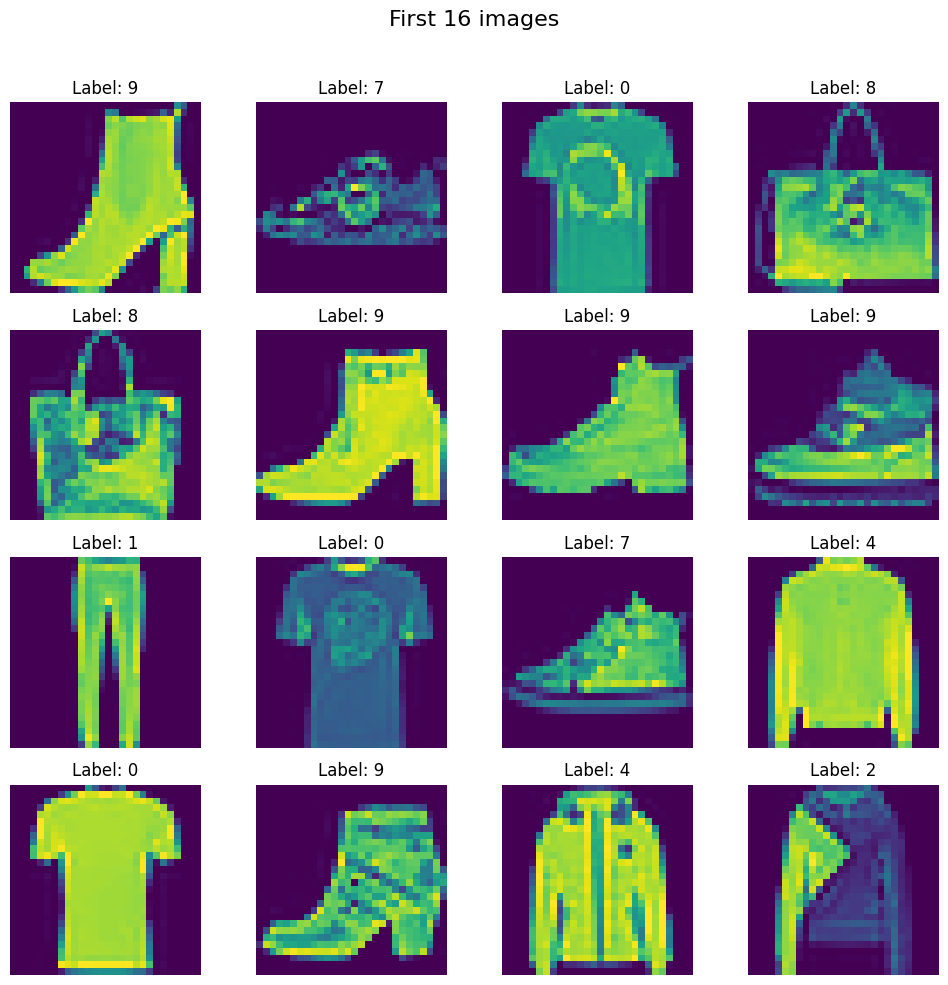

In [ ]:
# create a 4x4 grid of images
fig, axex = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 images", fontsize=16)

# plot the first 16 images from the dataset
for i, ax in enumerate(axex.flat):
    img = df.iloc[i, 1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [ ]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# define transformations
from torchvision.transforms import transforms

custom_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from PIL import Image
import numpy as np

class CustomDataset(Dataset):

    def __init__(self, features, labels, transform):
        self.features = features
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):

        # resize to 28 x 28
        image = self.features[index].reshape(28,28)

        # dtype to np.uint8
        image = image.astype(np.uint8)

        # 1 channel to 3 channels (H,W,C) not (C,H,W)
        image = np.stack([image]*3, axis=-1)

        # convert array to PIL image
        image = Image.fromarray(image)

        # apply transforms
        image = self.transform(image)

        # return
        return image, torch.tensor(self.labels[index], dtype=torch.long)

In [ ]:
train_dataset = CustomDataset(X_train, y_train, custom_transforms)
test_dataset = CustomDataset(X_test, y_test, custom_transforms)

In [ ]:
train_loader = DataLoader(train_dataset, 32, True, pin_memory=True) # create batches
test_loader = DataLoader(test_dataset, 32, True, pin_memory=True)

In [ ]:
len(train_loader)

24

### Pretrained Model

In [ ]:
# fetch the pretrained model

import torchvision.models as models

vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 77.0MB/s]


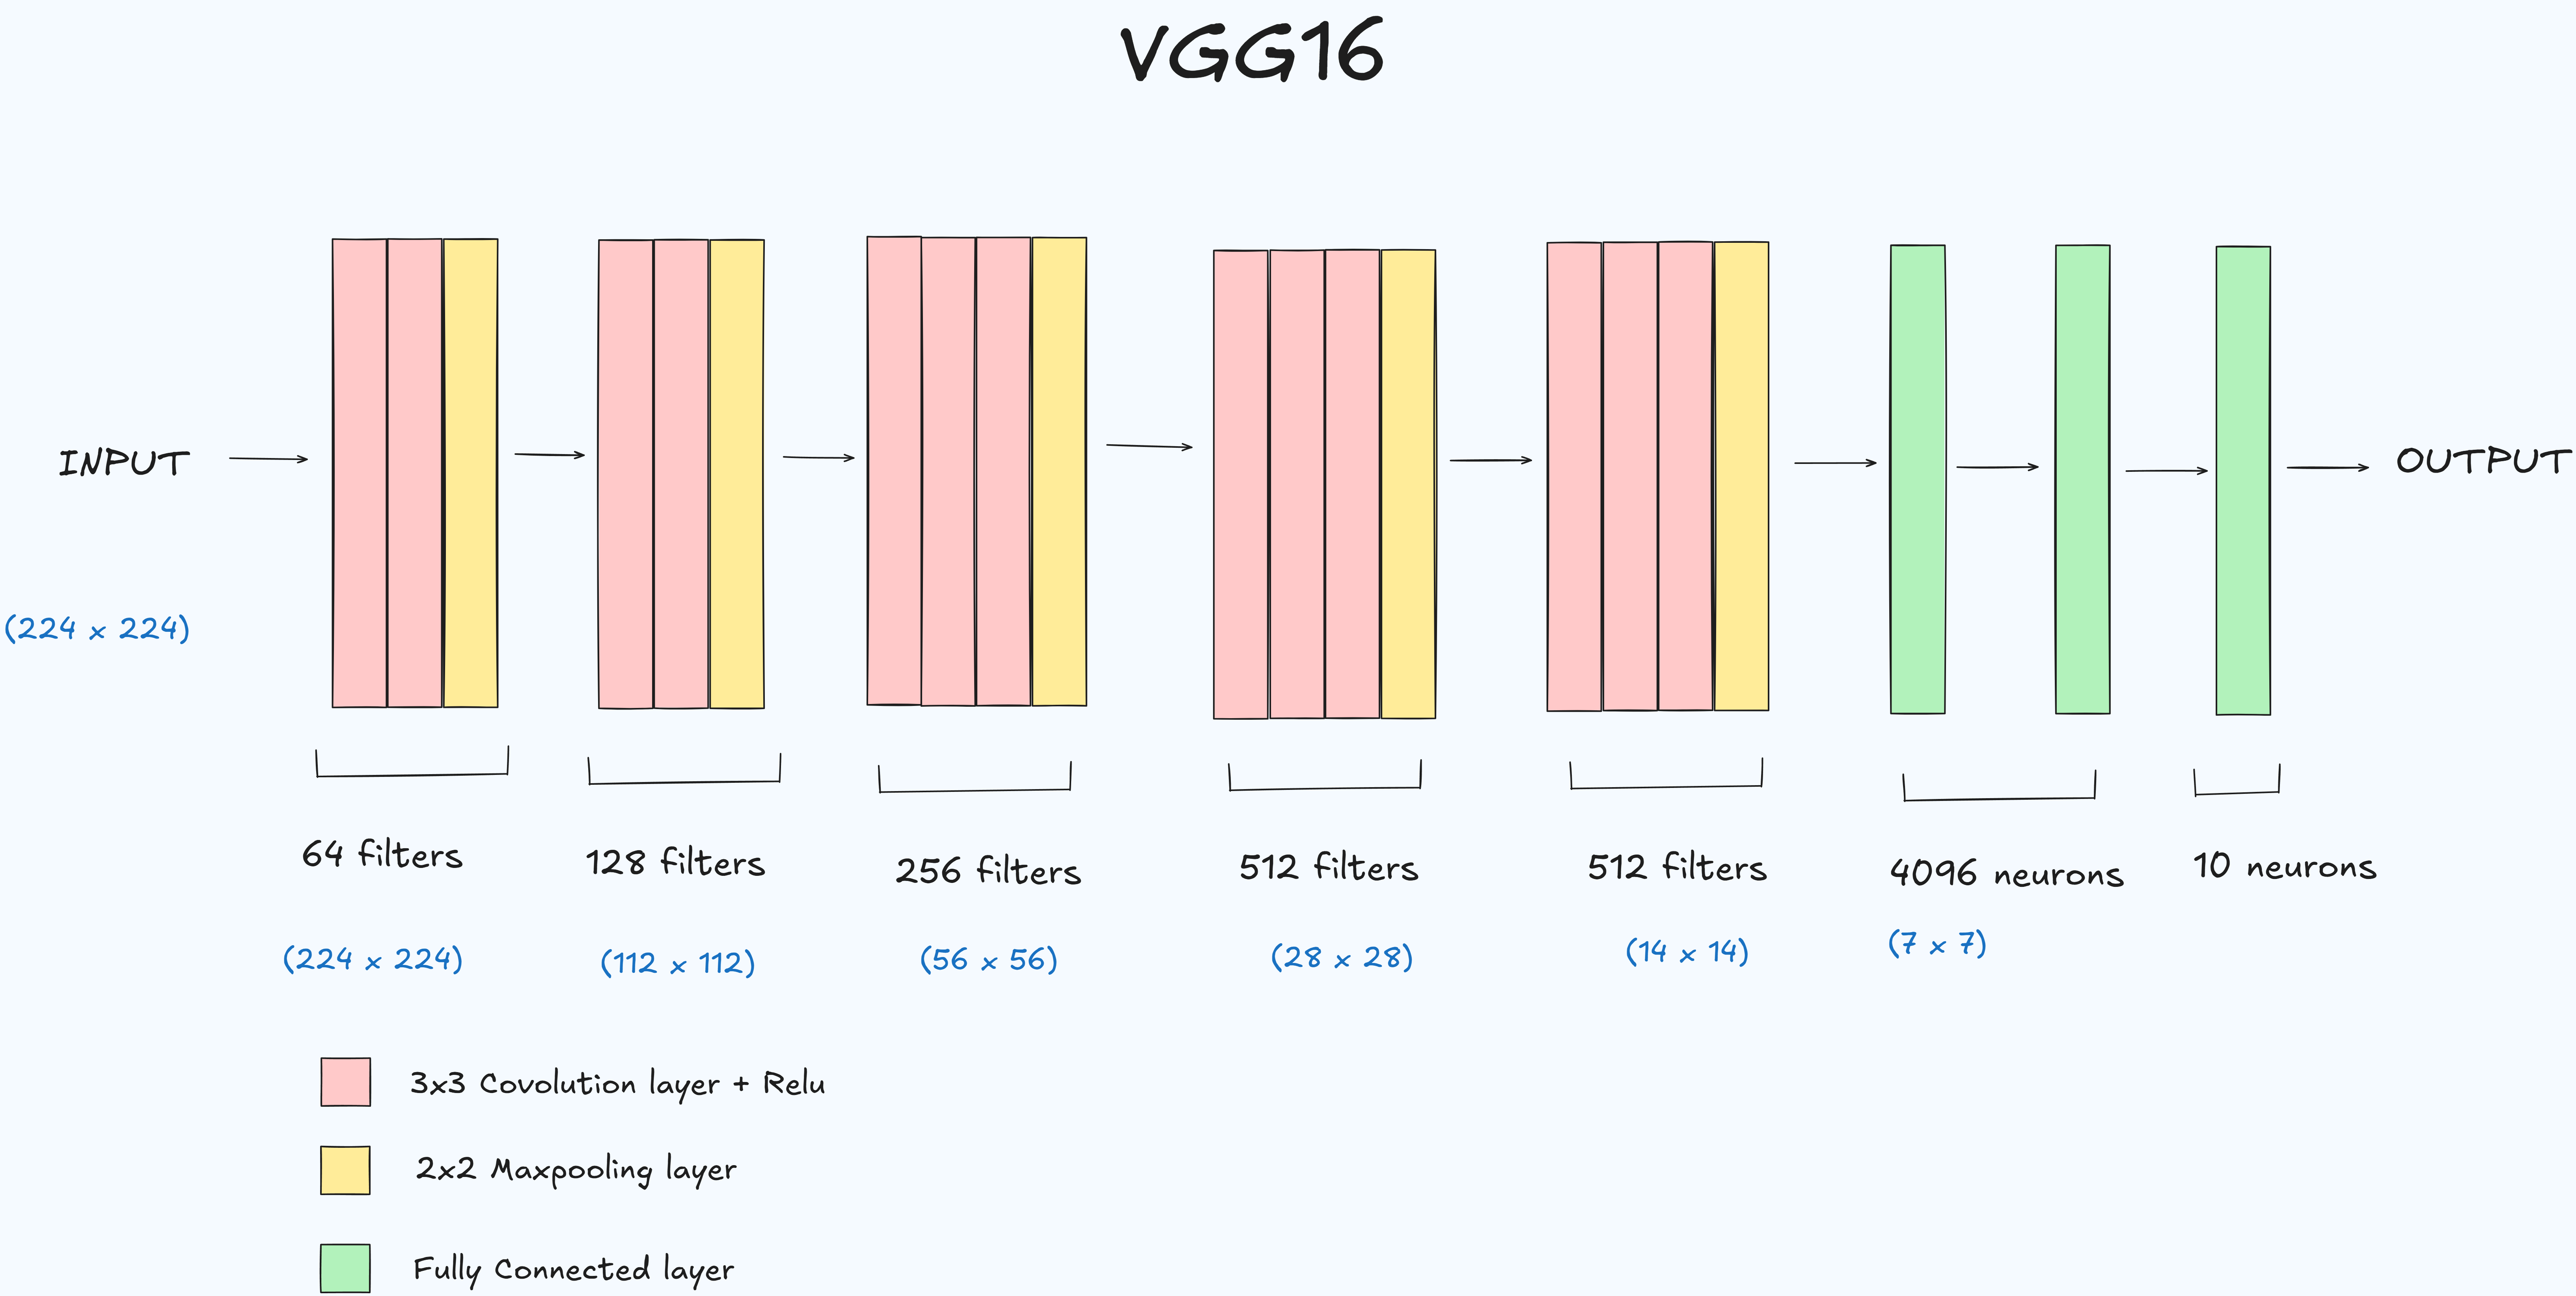

In [ ]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
vgg16.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [ ]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [ ]:
# freeze features parameters
for param in vgg16.features.parameters():
    param.requires_grad=False

In [ ]:
# replace with our classifier

vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(512, 10),
)

In [ ]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=1024, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=1024, out_features=512, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=512, out_features=10, bias=True)
)

In [ ]:
vgg16.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# check model's device
next(vgg16.parameters()).device


device(type='cuda', index=0)

In [ ]:
lr = 0.001
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr)

In [ ]:
# training loop

for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:

        # move data to cuda
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        # forward pass
        outputs = vgg16(batch_features)

        # calculate loss
        loss = criterion(outputs, batch_labels)

        # backward pass
        optimizer.zero_grad()
        loss.backward()

        # update grads
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader) # <- div by no. of batches
    print(f"Epoch: {epoch + 1}, Loss: {avg_loss}")

/tmp/ipykernel_635/828580172.py:20: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


Epoch: 1, Loss: 1.3838458160559337
Epoch: 2, Loss: 0.4957533907145262
Epoch: 3, Loss: 0.2513998265688618
Epoch: 4, Loss: 0.1631892117438838
Epoch: 5, Loss: 0.12062932845825951
Epoch: 6, Loss: 0.09339596270001493


/tmp/ipykernel_635/828580172.py:20: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


Epoch: 7, Loss: 0.0590158414755327
Epoch: 8, Loss: 0.03922514613562574
Epoch: 9, Loss: 0.06819517294934485
Epoch: 10, Loss: 0.07697625115361006


In [ ]:
vgg16.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# evaluate test data

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        # move data to cuda
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = vgg16(batch_features)

        _, predicted = torch.max(outputs, 1)

        total += batch_features.shape[0]

        correct += (predicted == batch_labels).sum().item()

    print(correct/total)

0.8351063829787234


In [ ]:
# evaluate train data

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:

        # move data to cuda
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = vgg16(batch_features)

        _, predicted = torch.max(outputs, 1)

        total += batch_features.shape[0]

        correct += (predicted == batch_labels).sum().item()

    print(correct/total)

/tmp/ipykernel_635/828580172.py:20: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


0.9906914893617021
